In [320]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
from skimage.metrics import structural_similarity, mean_squared_error

# Для изображения sar_3.jpg найти наиболее протяженный участок

In [321]:
image = plt.imread('images/sar_3.jpg')
image_copy1 = image.copy()
image_copy2 = image.copy()
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(image_gray, 7)
canny = cv2.Canny(blurred, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(canny, 1, np.pi / 180, threshold=45, minLineLength=40, maxLineGap=30)


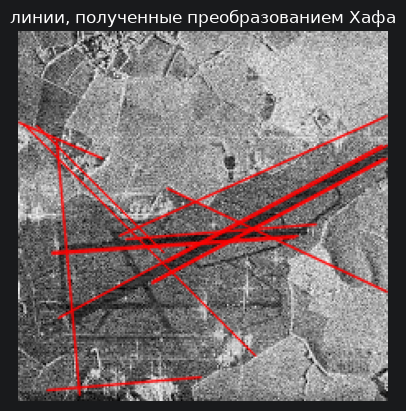

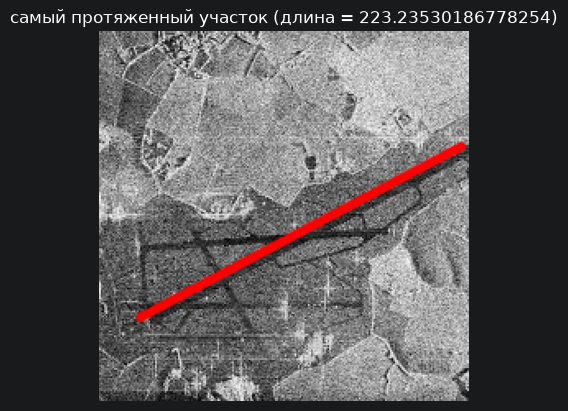

In [322]:
best_lenght = 0
best_line = None
if lines is not None:
    for i in range(len(lines)):
        x1, y1, x2, y2 = lines[i].flatten()
        length = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if length > best_lenght:
            best_lenght = length
            best_line = (x1, y1, x2, y2)
        cv2.line(image_copy1, (x1, y1), (x2, y2), (255, 0, 0), 1, cv2.LINE_AA)

plt.imshow(image_copy1)
plt.title('линии, полученные преобразованием Хафа')
plt.axis('off')
plt.show()
x1, y1, x2, y2 = best_line
cv2.line(image_copy2, (x1, y1), (x2, y2), (255, 0, 0), 3, cv2.LINE_AA)
plt.imshow(image_copy2)
plt.title(f'самый протяженный участок (длина = {best_lenght})')
plt.axis('off')
plt.show()